# Historical Stock Market Analysis (1970–2020)

## Introduction

This project analyzes historical stock market data to identify long-term trends in stock prices and trading activity across different decades.

The analysis uses two datasets:
- A stock information dataset containing company details such as ticker, exchange, sector, and industry.
- A historical stock price dataset containing daily stock information including opening price, closing price, highest and lowest prices, trading volume, and adjusted closing price.

The main objective of this project is to compare stock market behavior across decades by analyzing price trends, trading volume, volatility, and changes in market activity over time.

The analysis includes data cleaning, feature engineering, dataset merging, statistical analysis, and visualization techniques to better understand historical stock performance.

---

Github Repository Link: https://github.com/alyssaiapalucci4/historical-stock-analysis-project/new/main?readme=1

Google Colab Link: https://colab.research.google.com/drive/1E-hwbyzj3z8MQccuEw0eyHULK2Q8_jKu?usp=sharing

---

Student Information

**Student:** Alyssa Iapalucci

**Date:** July 2026

---

In [42]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [43]:
# Load datasets

stocks = pd.read_csv("historical_stocks.csv")
prices = pd.read_csv("historical_stock_prices.csv")

In [44]:
# Preview datasets

print("Stocks Dataset")
display(stocks.head())

print("Prices Dataset")
display(prices.head())

Stocks Dataset


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


Prices Dataset


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


In [45]:
# Dataset information

print("Stocks shape:", stocks.shape)
print("Prices shape:", prices.shape)

print("\nStocks columns:")
print(stocks.columns)

print("\nPrices columns:")
print(prices.columns)

Stocks shape: (6460, 5)
Prices shape: (20973889, 8)

Stocks columns:
Index(['ticker', 'exchange', 'name', 'sector', 'industry'], dtype='object')

Prices columns:
Index(['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume',
       'date'],
      dtype='object')


Part 2 — Data Cleaning

In [46]:
# Rename Columns

stocks.rename(columns={
    "ticker":"Ticker",
    "exchange":"Exchange",
    "name":"Name",
    "sector":"Sector",
    "industry":"Industry"
}, inplace=True)


prices.rename(columns={
    "ticker":"Ticker",
    "open":"Open",
    "close":"Close",
    "adj_close":"Adjusted Close",
    "low":"Low",
    "high":"High",
    "volume":"Volume",
    "date":"Date"
}, inplace=True)

In [47]:
# Missing Values
print("Stocks Missing Values")
print(stocks.isnull().sum())

print("\nPrices Missing Values")
print(prices.isnull().sum())

Stocks Missing Values
Ticker         0
Exchange       0
Name           0
Sector      1440
Industry    1440
dtype: int64

Prices Missing Values
Ticker            0
Open              0
Close             0
Adjusted Close    0
Low               0
High              0
Volume            0
Date              0
dtype: int64


In [48]:
# Handle Missing Values

stocks["Sector"] = stocks["Sector"].fillna("Unknown")
stocks["Industry"] = stocks["Industry"].fillna("Unknown")

prices.dropna(inplace=True)

In [49]:
# Remove Duplicates

print("Stock duplicates:", stocks.duplicated().sum())
print("Price duplicates:", prices.duplicated().sum())

stocks.drop_duplicates(inplace=True)
prices.drop_duplicates(inplace=True)

Stock duplicates: 0
Price duplicates: 0


In [50]:
# Date Conversion

prices["Date"] = pd.to_datetime(prices["Date"])

prices = prices.sort_values("Date")

prices.head()

,Ticker,Open,Close,Adjusted Close,Low,High,Volume,Date
4285669,XOM,1.929688,1.937500,0.025623,1.925781,1.937500,1174400,1970-01-02
14184994,AA,7.140915,7.140915,1.986261,7.140915,7.225020,22500,1970-01-02
15384996,BA,0.925926,0.979424,0.229325,0.925926,0.979424,634400,1970-01-02
18215303,DIS,0.688281,0.683144,0.282199,0.683144,0.689565,1109700,1970-01-02
18189682,PG,1.710938,1.718750,0.020346,1.708984,1.722656,832000,1970-01-02


Part 3 — Feature Engineering

In [51]:
# Create Year
prices["Year"] = prices["Date"].dt.year

In [52]:
# Create Decade
prices["Decade"] = (prices["Year"] // 10) * 10

prices.head()

,Ticker,Open,Close,Adjusted Close,Low,High,Volume,Date,Year,Decade
4285669,XOM,1.929688,1.937500,0.025623,1.925781,1.937500,1174400,1970-01-02,1970,1970
14184994,AA,7.140915,7.140915,1.986261,7.140915,7.225020,22500,1970-01-02,1970,1970
15384996,BA,0.925926,0.979424,0.229325,0.925926,0.979424,634400,1970-01-02,1970,1970
18215303,DIS,0.688281,0.683144,0.282199,0.683144,0.689565,1109700,1970-01-02,1970,1970
18189682,PG,1.710938,1.718750,0.020346,1.708984,1.722656,832000,1970-01-02,1970,1970


In [53]:
# Create Decade Groups
decades = {}

for decade in sorted(prices["Decade"].unique()):

    decades[decade] = prices[
        prices["Decade"] == decade
    ]

    print(
        decade,
        decades[decade].shape
    )

1970 (164499, 10)
1980 (1470571, 10)
1990 (3427832, 10)
2000 (6572053, 10)
2010 (9338934, 10)


In [56]:
# Part 4 — Merge Datasets
merged = prices.merge(
    stocks,
    on="Ticker",
    how="left"
)

merged.head()
print("Merged Shape:", merged.shape)

Merged Shape: (20973889, 14)


In [57]:
# Part 5 — Summary Statistics
summary = merged.groupby("Decade")[
    ["Open","High","Low","Close","Volume"]
].agg([
    "mean",
    "median",
    "std"
])


summary

Open                                High             \
              mean     median          std        mean     median   
Decade                                                              
1970     12.491493   2.791667    46.981142   12.640192   2.840909   
1980     16.814261   5.000000   573.048093   17.095074   5.083333   
1990     45.291459  10.583831  1391.110191   46.871896  10.750000   
2000    122.295850  16.580000  4485.636333  125.646271  16.866667   
2010     65.261101  20.010000  1820.181589   66.723946  20.285000   

                            Low                               Close  \
                std        mean     median          std        mean   
Decade                                                                
1970      47.481931   12.366931   2.765625    46.513085   12.491549   
1980     582.814179   16.561523   4.958333   562.257404   16.824845   
1990    1464.629619   43.814977  10.437500  1329.334616   45.303495   
2000    4703.968766  119.170676  16.299999  4318.821828  122.440812   
2010    1941.571402   63.917347  19.750000  1763.144292   65.278332   

                                      Volume                          
           median          std          mean    median           std  
Decade                                                                
1970     2.791667    46.985360  7.248936e+05  187200.0  1.377366e+06  
1980     5.000000   575.029287  8.375234e+05   64600.0  4.510088e+06  
1990    10.593750  1391.576526  8.635272e+05   62200.0  5.834012e+06  
2000    16.584999  4509.781698  1.383562e+06  133400.0  9.230143e+06  
2010    20.010000  1850.127729  1.320505e+06  165400.0  1.770789e+07

In [58]:
# Mean Closing Price Comparison
close_comparison = merged.groupby("Decade")["Close"].agg(
    ["mean","median"]
)

close_comparison

,mean,median
Decade,,
1970,12.491549,2.791667
1980,16.824845,5.000000
1990,45.303495,10.593750
2000,122.440812,16.584999
2010,65.278332,20.010000


In [59]:
# Volatility
volatility = merged.groupby("Decade")["Close"].std()

Part 6 — Visualization

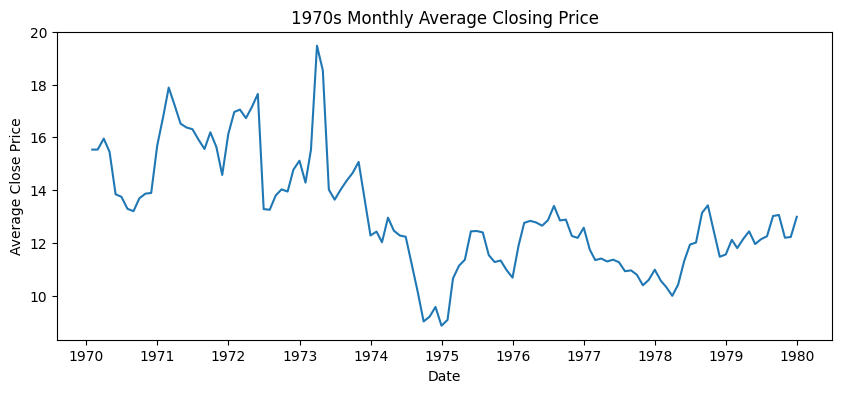

In [61]:
# Monthly Average Closing Price — 1970s

decade = 1970

decade_data = merged[
    merged["Decade"] == decade
].copy()

monthly_close = (
    decade_data
    .set_index("Date")["Close"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(10,4))

plt.plot(monthly_close)

plt.title(
    f"{decade}s Monthly Average Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.show()

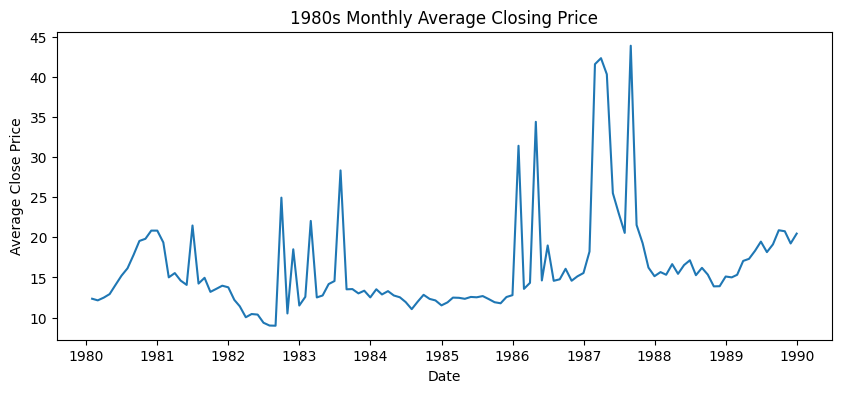

In [62]:
# Monthly Average Closing Price — 1980s

decade = 1980

decade_data = merged[
    merged["Decade"] == decade
].copy()

monthly_close = (
    decade_data
    .set_index("Date")["Close"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(10,4))

plt.plot(monthly_close)

plt.title(
    f"{decade}s Monthly Average Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.show()

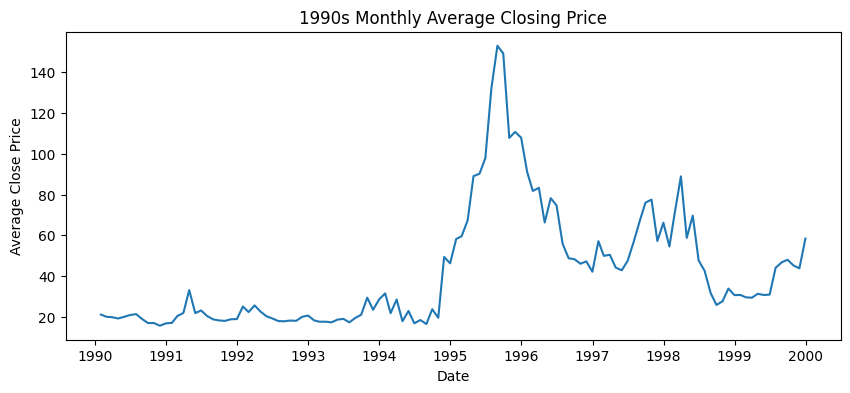

In [63]:
# Monthly Average Closing Price — 1990s
decade = 1990

decade_data = merged[
    merged["Decade"] == decade
].copy()

monthly_close = (
    decade_data
    .set_index("Date")["Close"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(10,4))

plt.plot(monthly_close)

plt.title(
    f"{decade}s Monthly Average Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.show()

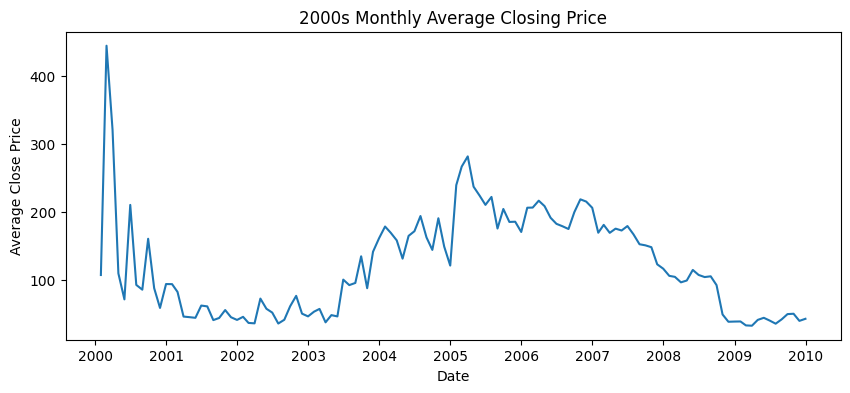

In [64]:
# Monthly Average Closing Price — 2000s

decade = 2000

decade_data = merged[
    merged["Decade"] == decade
].copy()

monthly_close = (
    decade_data
    .set_index("Date")["Close"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(10,4))

plt.plot(monthly_close)

plt.title(
    f"{decade}s Monthly Average Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.show()

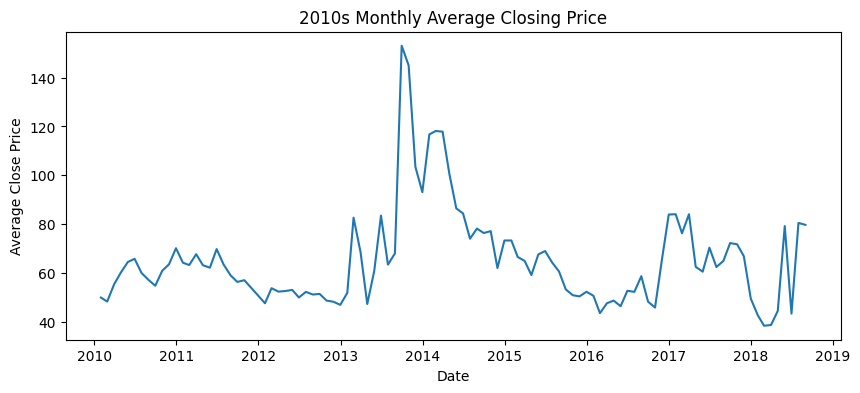

In [65]:
# Monthly Average Closing Price — 2010s
decade = 2010

decade_data = merged[
    merged["Decade"] == decade
].copy()

monthly_close = (
    decade_data
    .set_index("Date")["Close"]
    .resample("ME")
    .mean()
)

plt.figure(figsize=(10,4))

plt.plot(monthly_close)

plt.title(
    f"{decade}s Monthly Average Closing Price"
)

plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.show()

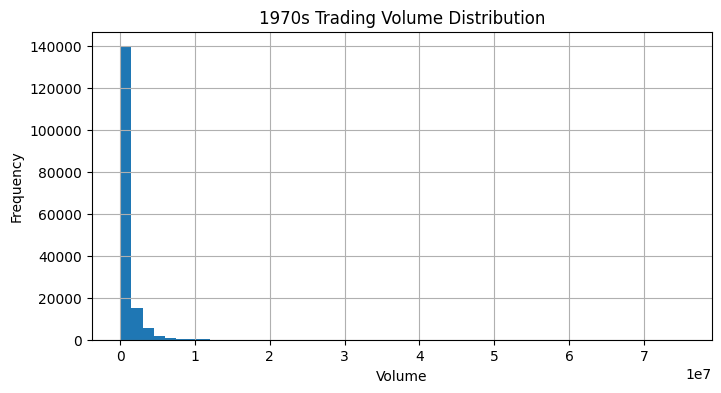

In [67]:
# Trading Volume Distribution — 1970s

decade = 1970

volume_data = merged[
    merged["Decade"] == decade
]["Volume"]


plt.figure(figsize=(8,4))

volume_data.hist(bins=50)

plt.title(
    f"{decade}s Trading Volume Distribution"
)

plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

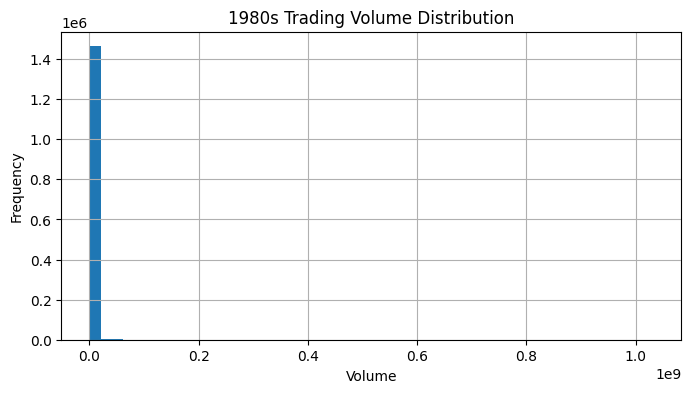

In [68]:
# Trading Volume Distribution — 1980s
decade = 1980

volume_data = merged[
    merged["Decade"] == decade
]["Volume"]


plt.figure(figsize=(8,4))

volume_data.hist(bins=50)

plt.title(
    f"{decade}s Trading Volume Distribution"
)

plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

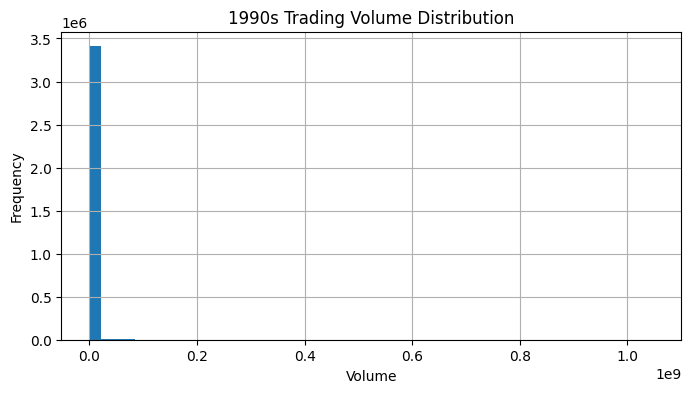

In [69]:
# Trading Volume Distribution — 1990s
decade = 1990

volume_data = merged[
    merged["Decade"] == decade
]["Volume"]


plt.figure(figsize=(8,4))

volume_data.hist(bins=50)

plt.title(
    f"{decade}s Trading Volume Distribution"
)

plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

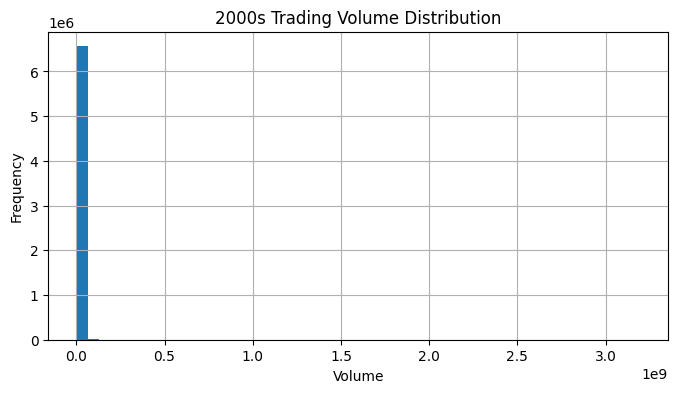

In [70]:
# Trading Volume Distribution — 2000s
decade = 2000

volume_data = merged[
    merged["Decade"] == decade
]["Volume"]


plt.figure(figsize=(8,4))

volume_data.hist(bins=50)

plt.title(
    f"{decade}s Trading Volume Distribution"
)

plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

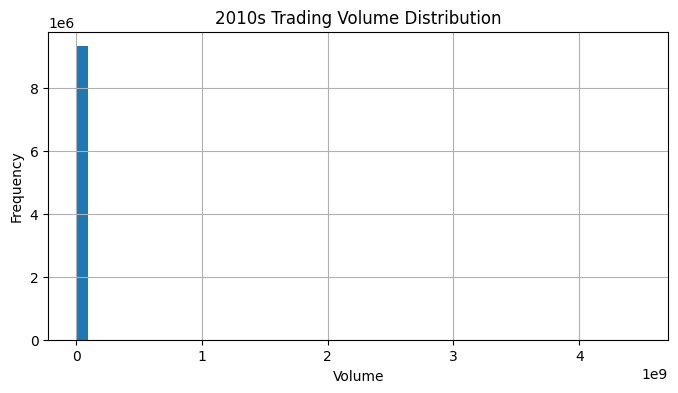

In [71]:
# Trading Volume Distribution — 2010s
decade = 2010

volume_data = merged[
    merged["Decade"] == decade
]["Volume"]


plt.figure(figsize=(8,4))

volume_data.hist(bins=50)

plt.title(
    f"{decade}s Trading Volume Distribution"
)

plt.xlabel("Volume")
plt.ylabel("Frequency")

plt.show()

<Figure size 600x400 with 0 Axes>

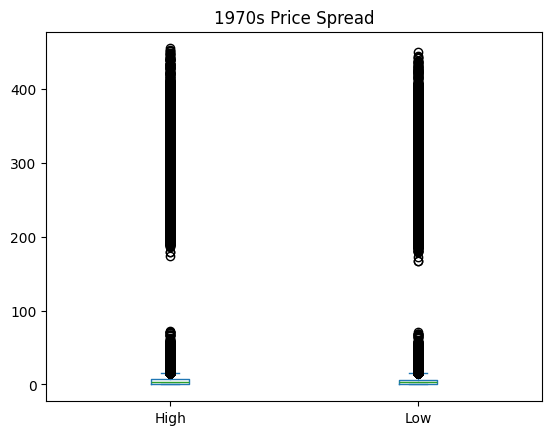

In [74]:
# Box Plot - Price Spread — 1970s
decade = 1970

price_data = merged[
    merged["Decade"] == decade
][["High","Low"]]


plt.figure(figsize=(6,4))

price_data.plot(
    kind="box"
)

plt.title(
    f"{decade}s Price Spread"
)

plt.show()

<Figure size 600x400 with 0 Axes>

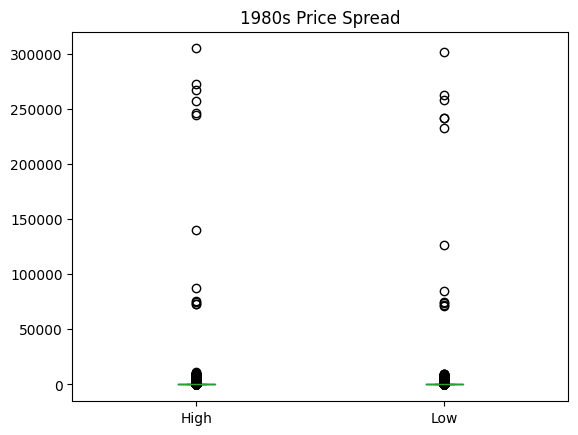

In [75]:
# Box Plot - Price Spread — 1980s
decade = 1980

price_data = merged[
    merged["Decade"] == decade
][["High","Low"]]


plt.figure(figsize=(6,4))

price_data.plot(
    kind="box"
)

plt.title(
    f"{decade}s Price Spread"
)

plt.show()

<Figure size 600x400 with 0 Axes>

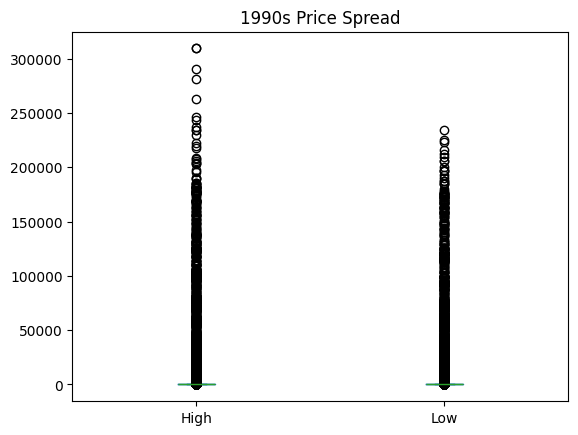

In [76]:
# Box Plot - Price Spread — 1990s
decade = 1990

price_data = merged[
    merged["Decade"] == decade
][["High","Low"]]


plt.figure(figsize=(6,4))

price_data.plot(
    kind="box"
)

plt.title(
    f"{decade}s Price Spread"
)

plt.show()

<Figure size 600x400 with 0 Axes>

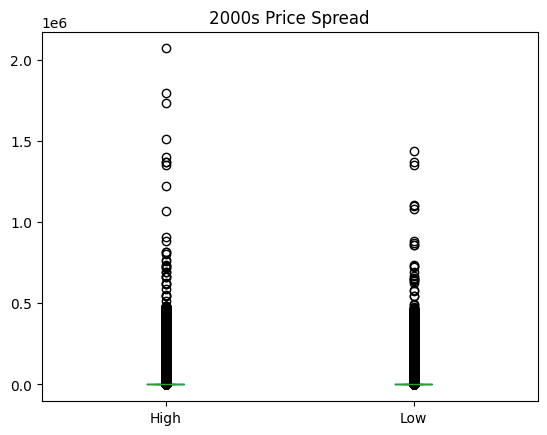

In [77]:
# Box Plot - Price Spread — 2000s
decade = 2000

price_data = merged[
    merged["Decade"] == decade
][["High","Low"]]


plt.figure(figsize=(6,4))

price_data.plot(
    kind="box"
)

plt.title(
    f"{decade}s Price Spread"
)

plt.show()

<Figure size 600x400 with 0 Axes>

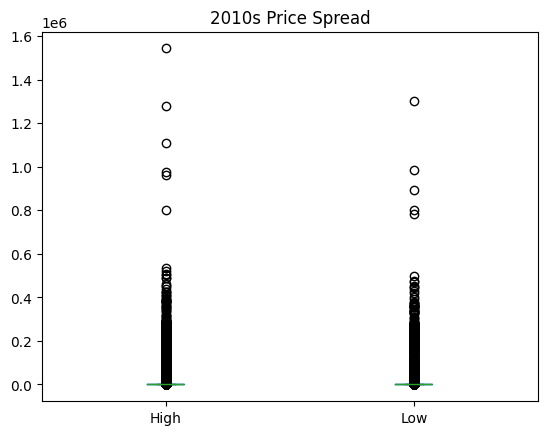

In [78]:
# Box Plot - Price Spread — 2010s
decade = 2010

price_data = merged[
    merged["Decade"] == decade
][["High","Low"]]


plt.figure(figsize=(6,4))

price_data.plot(
    kind="box"
)

plt.title(
    f"{decade}s Price Spread"
)

plt.show()

In [79]:
# Part 7 — Final Comparison Table
final_comparison = merged.groupby("Decade")[
    ["Close","Volume"]
].mean()


final_comparison

,Close,Volume
Decade,,
1970,12.491549,7.248936e+05
1980,16.824845,8.375234e+05
1990,45.303495,8.635272e+05
2000,122.440812,1.383562e+06
2010,65.278332,1.320505e+06
